# Climatological Temporal Evolution of IKE

Three 2-panel figures, each comparing IKE evolution over a storm's lifecycle against a
different secondary variable (Vmax, Pmin, or R34): panel a) IKE vs. normalized lifetime
(0-100%) with the secondary variable on a twin axis, panel b) IKE aligned to t=0 at that
variable's own peak (±72 hours).

## Paths

See the repo README ("Setting IBTRACS_PATH / IKE_OUTPUT_DIR")
for why these are set here rather than relying on a shell-level `export`.

In [1]:
import os
os.environ["IBTRACS_PATH"] = "/home/sydney.e.walters/IBTrACS"
os.environ["IKE_OUTPUT_DIR"] = "/home/sydney.e.walters/IBTrACS_Manuscript_Figures"


## Imports

In [2]:
import warnings

import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

from ike_climatology import config
from ike_climatology.ibtracs_io import load_master_dataframe
from ike_climatology.style import BASIN_COLORS, DESIRED_BASIN_ORDER


## Data extraction

In [3]:
master_df = load_master_dataframe(
    basins=config.BASINS_TO_ANALYZE,
    file_map=config.IBTRACS_FILE_MAP,
    basin_codes=config.IBTRACS_BASIN_CODES,
    start_year=config.START_YEAR,
    end_year=config.END_YEAR,
    land_interaction_threshold_km=config.LAND_INTERACTION_THRESHOLD_KM,
)

if master_df.empty:
    raise RuntimeError("No processable storm data found -- check IBTRACS_PATH.")


--- Starting Initial Data Loading and Processing for All Basins ---
    - Loading IBTrACS data for North Atlantic (2004-2024)
        Found 380 storms in file.
        - Filtered out 2 crossover/external storms based on official genesis basin label.
    - Loading IBTrACS data for East Pacific (2004-2024)
        Found 497 storms in file.
        - Filtered out 79 crossover/external storms based on official genesis basin label.
    - Loading IBTrACS data for West Pacific (2004-2024)
        Found 622 storms in file.
        - Filtered out 16 crossover/external storms based on official genesis basin label.
    - Loading IBTrACS data for North Indian (2004-2024)
        Found 220 storms in file.
        - Filtered out 13 crossover/external storms based on official genesis basin label.
    - Loading IBTrACS data for South Indian (2004-2024)
        Found 367 storms in file.
        - Filtered out 22 crossover/external storms based on official genesis basin label.
    - Loading IBTrACS data

## Build lifecycle arrays

For each storm: skip if fewer than 4 observations, peak Vmax < 34 kt, or the storm
never produced positive IKE. Otherwise build a normalized-lifetime IKE curve
(interpolated onto 0-100%, 101 points) and three separate ±72-hour alignments
(6-hourly, 25 points each) centered on peak Vmax, minimum Pmin, and peak R34
respectively -- these three anchors generally fall at different times within the
same storm, so each needs its own alignment rather than sharing one.

In [4]:
norm_dict = {
    "time_norm": np.linspace(0, 100, 101),
    "global_vmax": [], "global_pmin": [], "global_r34": [],
}
for b in DESIRED_BASIN_ORDER:
    norm_dict[b] = []

t_zero_dict_vmax = {b: [] for b in DESIRED_BASIN_ORDER}
t_zero_dict_pmin = {b: [] for b in DESIRED_BASIN_ORDER}
t_zero_dict_r34 = {b: [] for b in DESIRED_BASIN_ORDER}

for storm_id, group in master_df.groupby("storm_id"):
    if len(group) < 4 or group["vmax_kts"].max() < 34:
        continue

    basin = group["basin"].iloc[0]
    ike_history = group["total_ike_tj"].fillna(0).values
    vmax_history = group["vmax_kts"].fillna(0).values

    pmin_series = group["pmin_mb"].interpolate(method="linear").ffill().bfill()
    pmin_history = pmin_series.values
    r34_history = group["r34_km"].fillna(0).values

    if np.max(ike_history) <= 0:
        continue

    peak_idx_vmax = np.argmax(vmax_history)
    peak_idx_r34 = np.argmax(r34_history)

    if np.isnan(pmin_history).all():
        peak_idx_pmin = peak_idx_vmax  # fallback to wind if no pressure data exists
    else:
        peak_idx_pmin = np.nanargmin(pmin_history)

    aligned_ike_vmax = np.full(25, np.nan)
    aligned_ike_pmin = np.full(25, np.nan)
    aligned_ike_r34 = np.full(25, np.nan)

    for idx_offset, offset in enumerate(range(-12, 13)):
        target_vmax = peak_idx_vmax + offset
        if 0 <= target_vmax < len(ike_history):
            aligned_ike_vmax[idx_offset] = ike_history[target_vmax]

        target_pmin = peak_idx_pmin + offset
        if 0 <= target_pmin < len(ike_history):
            aligned_ike_pmin[idx_offset] = ike_history[target_pmin]

        target_r34 = peak_idx_r34 + offset
        if 0 <= target_r34 < len(ike_history):
            aligned_ike_r34[idx_offset] = ike_history[target_r34]

    t_zero_dict_vmax[basin].append(aligned_ike_vmax)
    t_zero_dict_pmin[basin].append(aligned_ike_pmin)
    t_zero_dict_r34[basin].append(aligned_ike_r34)

    storm_time_array = np.linspace(0, 100, len(ike_history))
    norm_dict[basin].append(np.interp(norm_dict["time_norm"], storm_time_array, ike_history))
    norm_dict["global_vmax"].append(np.interp(norm_dict["time_norm"], storm_time_array, vmax_history))
    norm_dict["global_pmin"].append(np.interp(norm_dict["time_norm"], storm_time_array, pmin_history))
    norm_dict["global_r34"].append(np.interp(norm_dict["time_norm"], storm_time_array, r34_history))

print(f"{sum(len(v) for b, v in norm_dict.items() if b in DESIRED_BASIN_ORDER)} storms retained across all basins.")


1708 storms retained across all basins.


## Shared plotting function

In [5]:
SECONDARY_CONFIGS = {
    "vmax": dict(
        global_key="global_vmax", ylabel="Global Average Maximum Sustained Wind (kts)",
        legend_label=r"Global Avg $V_{max}$ (kts)", invert_secondary=False,
        panelA_title="a) Evolution of Total IKE over Normalized Lifetimes",
        panelB_title="b) IKE Evolution Relative to Maximum Intensity",
        panelB_xlabel="Hours Relative to Peak Intensity ($t = 0$)",
        filename="temporal_evolution_combined.png",
    ),
    "pmin": dict(
        global_key="global_pmin", ylabel="Global Average Minimum Central Pressure (hPa)",
        legend_label=r"Global Avg $P_{min}$ (hPa)", invert_secondary=True,
        panelA_title="a) Evolution of Total IKE vs. Central Pressure",
        panelB_title="b) IKE Evolution Relative to Minimum Pressure",
        panelB_xlabel="Hours Relative to Minimum Central Pressure ($t = 0$)",
        filename="temporal_evolution_pmin.png",
    ),
    "r34": dict(
        global_key="global_r34", ylabel="Global Average 34-kt Wind Radius (km)",
        legend_label=r"Global Avg $R_{34}$ (km)", invert_secondary=False,
        panelA_title="a) Evolution of Total IKE vs. Wind Field Expansion",
        panelB_title="b) IKE Evolution Relative to Max Wind Radius",
        panelB_xlabel="Hours Relative to Maximum Spatial Extent ($t = 0$)",
        filename="temporal_evolution_r34.png",
    ),
}


def plot_combined_lifecycle(secondary, t_zero_dict, output_dir):
    cfg = SECONDARY_CONFIGS[secondary]
    print(f"  > Generating Combined Lifecycle Figure ({secondary})...")

    fig, axes = plt.subplots(1, 2, figsize=(22, 9))
    plt.subplots_adjust(wspace=0.25)

    # --- Panel A: Normalized Lifetime -----------------------------------------
    ax1 = axes[0]
    x_norm = norm_dict["time_norm"]
    lines_a, labels_a = [], []

    for basin in DESIRED_BASIN_ORDER:
        basin_data = norm_dict[basin]
        if len(basin_data) == 0:
            continue
        ike_matrix = np.vstack(basin_data)
        mean_curve = np.nanmean(ike_matrix, axis=0)
        se = stats.sem(ike_matrix, axis=0, nan_policy="omit")
        ci_95 = se * stats.t.ppf((1 + 0.95) / 2.0, len(ike_matrix) - 1)

        color = BASIN_COLORS.get(basin, "gray")
        l, = ax1.plot(x_norm, mean_curve, color=color, linewidth=3, label=f"{basin} (n={len(ike_matrix)})")
        ax1.fill_between(x_norm, mean_curve - ci_95, mean_curve + ci_95, color=color, alpha=0.1)
        lines_a.append(l)
        labels_a.append(f"{basin} (n={len(ike_matrix)})")

    global_key = cfg["global_key"]
    if global_key in norm_dict and len(norm_dict[global_key]) > 0:
        ax2 = ax1.twinx()
        secondary_matrix = np.vstack(norm_dict[global_key])
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            secondary_mean = np.nanmean(secondary_matrix, axis=0)
        l_sec, = ax2.plot(x_norm, secondary_mean, color="black", linewidth=3.5, linestyle="--", label=cfg["legend_label"])
        ax2.set_ylabel(cfg["ylabel"], color="black", fontsize=14, fontweight="bold")
        if cfg["invert_secondary"]:
            ax2.invert_yaxis()
        else:
            ax2.set_ylim(0, np.nanmax(secondary_mean) * 1.4)
        lines_a.append(l_sec)
        labels_a.append(cfg["legend_label"])

    ax1.set_xlim(0, 100); ax1.set_ylim(0, 55)
    ax1.set_xlabel("Normalized Storm Lifetime (%)", fontsize=14, fontweight="bold")
    ax1.set_ylabel("Average Total IKE (TJ)", fontsize=14, fontweight="bold")
    ax1.set_title(cfg["panelA_title"], fontsize=18, fontweight="bold")
    ax1.grid(True, linestyle=":", alpha=0.7)

    ordered_lines, ordered_labels = [], []
    for target in DESIRED_BASIN_ORDER:
        for l, label in zip(lines_a, labels_a):
            if label.startswith(target):
                ordered_lines.append(l); ordered_labels.append(label); break
    if lines_a:
        ordered_lines.append(lines_a[-1]); ordered_labels.append(labels_a[-1])
    ax1.legend(ordered_lines, ordered_labels, fontsize=11, loc="upper left")

    # --- Panel B: T=0 Alignment ------------------------------------------------
    ax3 = axes[1]
    time_hours = np.arange(-72, 73, 6)

    for basin in DESIRED_BASIN_ORDER:
        basin_data = t_zero_dict[basin]
        if len(basin_data) == 0:
            continue
        ike_matrix = np.vstack(basin_data)
        mean_curve = np.nanmean(ike_matrix, axis=0)
        se = stats.sem(ike_matrix, axis=0, nan_policy="omit")
        ci_95 = se * stats.t.ppf((1 + 0.95) / 2.0, len(ike_matrix) - 1)

        color = BASIN_COLORS.get(basin, "gray")
        ax3.plot(time_hours, mean_curve, color=color, linewidth=3)
        valid_mask = ~np.isnan(mean_curve)
        ax3.fill_between(time_hours[valid_mask], (mean_curve - ci_95)[valid_mask],
                          (mean_curve + ci_95)[valid_mask], color=color, alpha=0.15)

    ax3.axvline(x=0, color="black", linestyle="--", linewidth=1.5, alpha=0.8)
    ax3.set_xlim(-72, 72); ax3.set_ylim(0, 55)
    ax3.set_xlabel(cfg["panelB_xlabel"], fontsize=14, fontweight="bold")
    ax3.set_ylabel("Average Total IKE (TJ)", fontsize=14, fontweight="bold")
    ax3.set_title(cfg["panelB_title"], fontsize=18, fontweight="bold")
    ax3.grid(True, linestyle=":", alpha=0.7)

    plt.suptitle(f"Climatological Temporal Evolution of IKE ({config.START_YEAR}-{config.END_YEAR})",
                 fontsize=20, fontweight="bold", y=0.98)
    os.makedirs(output_dir, exist_ok=True)
    plt.savefig(os.path.join(output_dir, cfg["filename"]), dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()


## Figure 1: IKE vs. Vmax

  > Generating Combined Lifecycle Figure (vmax)...


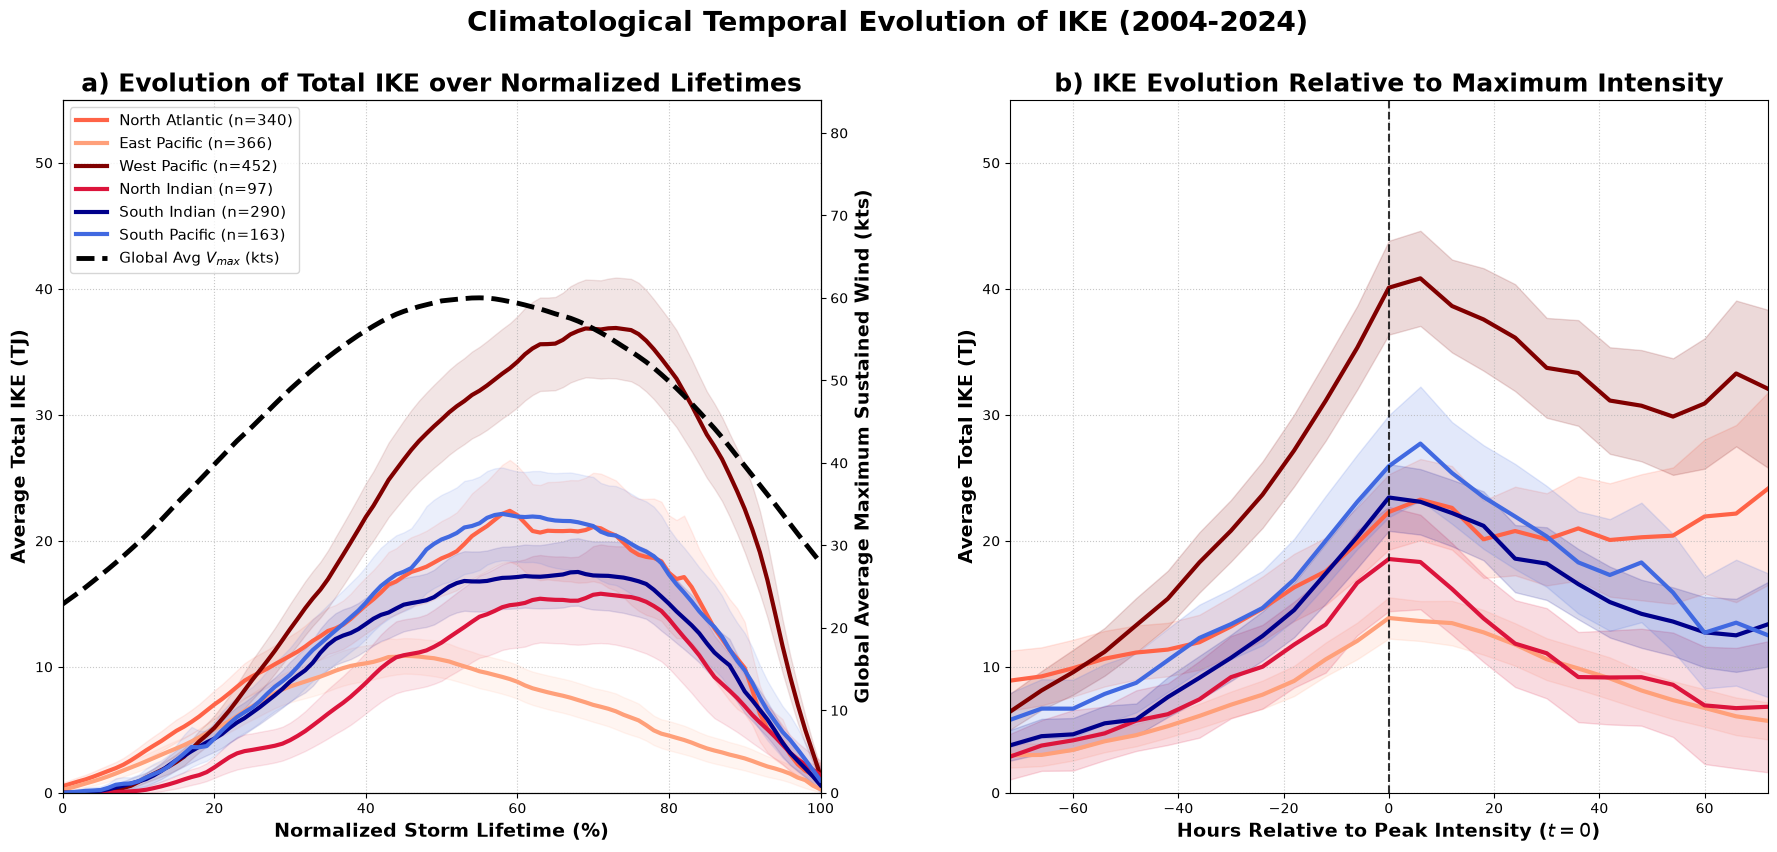

In [6]:
plot_combined_lifecycle("vmax", t_zero_dict_vmax, config.BASE_OUTPUT_DIR)


## Figure 2: IKE vs. Pmin

  > Generating Combined Lifecycle Figure (pmin)...


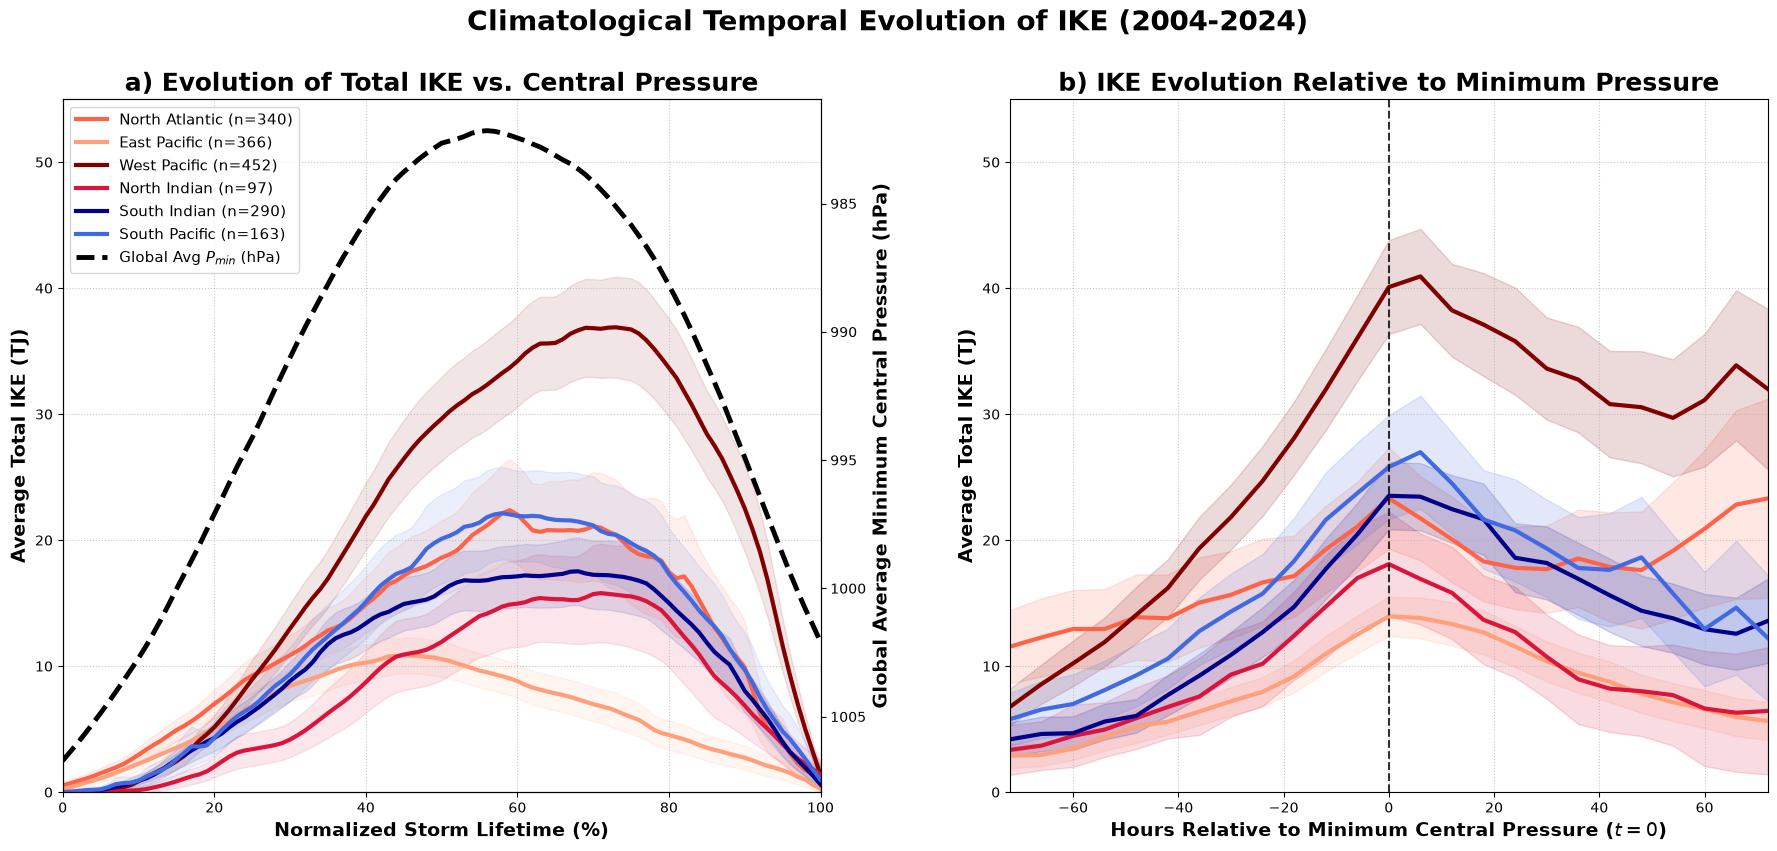

In [7]:
plot_combined_lifecycle("pmin", t_zero_dict_pmin, config.BASE_OUTPUT_DIR)


## Figure 3: IKE vs. R34

  > Generating Combined Lifecycle Figure (r34)...


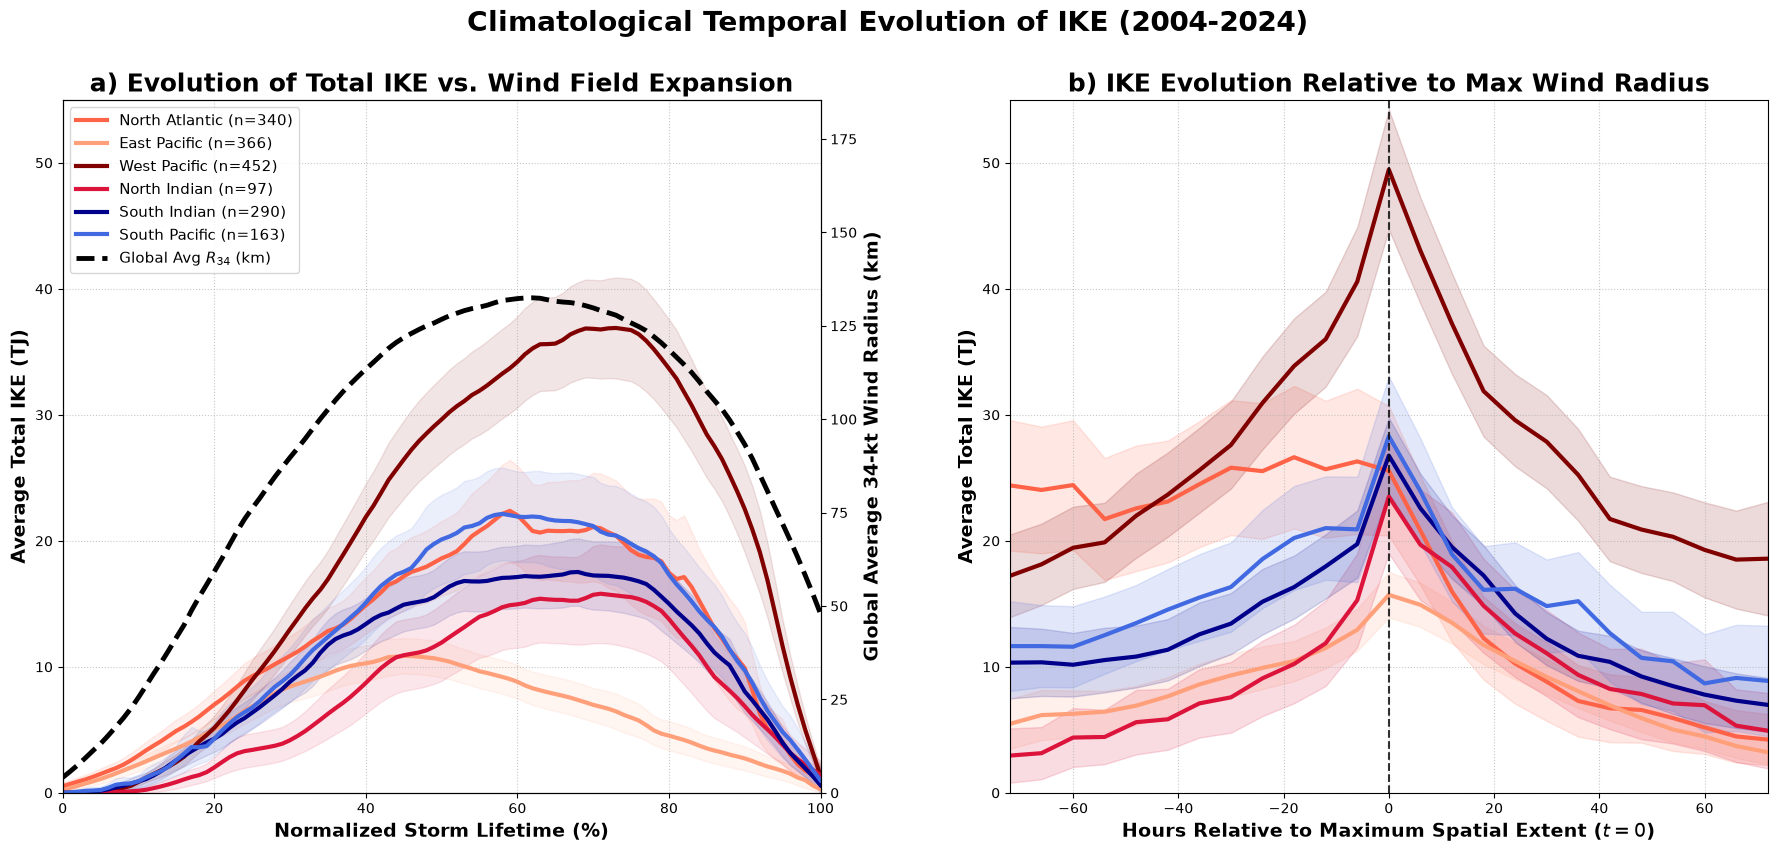

In [8]:
plot_combined_lifecycle("r34", t_zero_dict_r34, config.BASE_OUTPUT_DIR)
